In [1]:
#filtering Denisovan segments in East Asians:
# keeping ones longer than 40,000bp AND 0.05cM, 
# and with number of derived allels avaible to match Denisova3 >=30
# and with number of derived allels  uniquely matching Neanderthals <=1
# and with overall match rate to Denisova3 >=0.3

#keep longest one if any overlapping
import pandas as pd
import numpy as np
df = pd.read_csv('All_EA.bed', sep = '\s+',
                         names=['ind', 'chr', 'start', 'end', 'length', 
                                'map_start','map_end','map_len','method',
                                'd1','d2','n','d','s'])
#get a new column by split df['d1'] by '/'
df['d1_m'] = df['d1'].str.split('/').str[0].astype(int)
df['d1_t'] = df['d1'].str.split('/').str[1].astype(int)
df['d2_m'] = df['d2'].str.split('/').str[0].astype(int)
df['d2_t'] = df['d2'].str.split('/').str[1].astype(int)
df = df[(df['length']>=40000)&(df['map_len']>=0.0499)&(df['d1_t']>=30)]
df.sort_values(by=['chr','start'], inplace=True)
df = df.reset_index(drop=True)
#df.to_csv('All_EA_filtered.bed', sep = '\t', index=False, header=False)     #save all segments.
df_c = pd.DataFrame(columns=['ind', 'chr', 'start', 'end', 'length','map_start','map_end','map_len','method','d1','d2','n','d','s','d1_m','d1_t','d2_m','d2_t'])
df['d3_match'] = df['d1_m'] / df['d1_t']

df = df[(df['n']<=1) & (df['d3_match']>=0.3)]
df = df.reset_index(drop=True)
from collections import defaultdict

# keep none overlapping fragments, retaining the longest one if any overlap
a = defaultdict(lambda: defaultdict(list))
c = df.loc[0,'chr']
s = df.loc[0,'start']
e = df.loc[0,'end']
l = df.loc[0,'length']
m = df.loc[0,'map_len']
ind = df.loc[0,'ind']
n = 0
for i in range(len(df)):
    c_ = df.loc[i,'chr']
    s_ = df.loc[i,'start']
    e_ = df.loc[i,'end']
    l_ = df.loc[i,'length']
    m_ = df.loc[i,'map_len']
    ind_ = df.loc[i,'ind']
    if c_ == c: #still same chr
        if s_ <= e: #still same frag:
            if l_ > l:   # move to a longer one. use this one
                c = c_
                s = s_
                e = e_
                l = l_
                ind = ind_
        else:
            a[n]['chr'] = c
            a[n]['start'] = s
            a[n]['end'] = e
            a[n]['length'] = l
            a[n]['ind'] = ind
            c = df.loc[i,'chr']
            s = df.loc[i,'start']
            e = df.loc[i,'end']
            l = df.loc[i,'length']
            m = df.loc[i,'map_len']
            ind = df.loc[i,'ind']
            n += 1
    else:
        a[n]['chr'] = c
        a[n]['start'] = s
        a[n]['end'] = e
        a[n]['length'] = l
        a[n]['ind'] = ind
        c = df.loc[i,'chr']
        s = df.loc[i,'start']
        e = df.loc[i,'end']
        l = df.loc[i,'length']
        m = df.loc[i,'map_len']
        ind = df.loc[i,'ind']
        n += 1
        
df_ = pd.DataFrame(columns = ['chr','start','end','length','ind'])
for keys in list(a.keys()):
    print(keys)
    df_ = df_.append(a[keys],ignore_index=True)
df_ = df_.append({'chr':22,'start':48021000,'end':48218000,'length':197000,'ind':"S_Uygur-2"},ignore_index=True)   # the last non-overlapping fragment in East Asians > 0.3
#df_ = df_.append({'chr':22,'start':48022000,'end':48269000,'length':247000,'ind':"S_Xibo-1"},ignore_index=True)   # the last non-overlapping fragment in East Asians > 0.2

df_g = pd.merge(df,df_,on=['chr','start','end','length','ind'],how='inner')
df_g.sort_values(by=['chr','start'], inplace=True)
df_g = df_g[['chr','start','end','length','map_start','map_end','map_len','method','d1','d2','n','d','s','d1_m','d1_t','d2_m','d2_t','d3_match','ind']]      #final file for likelihood ratio tests
#df_g.to_csv('All_EA_filtered.non_verlap.bed', sep = '\t', index=False, header=False)  # write to file

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154


/tmp/ipykernel_1683684/4131618674.py:84: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_ = df_.append(a[keys],ignore_index=True)
/tmp/ipykernel_1683684/4131618674.py:84: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_ = df_.append(a[keys],ignore_index=True)
/tmp/ipykernel_1683684/4131618674.py:84: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_ = df_.append(a[keys],ignore_index=True)
/tmp/ipykernel_1683684/4131618674.py:84: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_ = df_.append(a[keys],ignore_index=True)
/tmp/ipykernel_1683684/4131618674.py:84: FutureWarning: The frame.append method is deprecated and will be removed from p

In [2]:
#likelihood ratio test to determine how many Denisovan components are there in present-day SGDP East Asians

from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

# Fit unimodal (1-component) and bimodal (2-component) GMMs
gmm_unimodal = GaussianMixture(n_components=1, random_state=0).fit(df_g[['d3_match']])
gmm_bimodal = GaussianMixture(n_components=2, random_state=0).fit(df_g[['d3_match']])

print("under a unimodal distribution, mean and std:" , gmm_unimodal.means_, np.sqrt(gmm_unimodal.covariances_))

# Calculate log-likelihoods
log_likelihood_unimodal = gmm_unimodal.score(df_g[['d3_match']]) * len(df_g[['d3_match']])
log_likelihood_bimodal = gmm_bimodal.score(df_g[['d3_match']]) * len(df_g[['d3_match']])

# Compute test statistic
D12 = -2 * (log_likelihood_unimodal - log_likelihood_bimodal)
D12_p_value = chi2.sf(D12, df=3)  # 3 degrees of freedom (difference in model parameters)

# D23 = -2 * (log_likelihood_bimodal - log_likelihood_trimodal)
# D23_p_value = chi2.sf(D23, df=3)  # 3 degrees of freedom (difference in model parameters)

import numpy as np
means = gmm_bimodal.means_.flatten()
std_devs = np.sqrt(gmm_bimodal.covariances_).flatten()
weights = gmm_bimodal.weights_.flatten()
print("weights under a bimodal distribution for Denisovan segments in SGDP East Asians:", weights)
print("means under a bimodal distribution for Denisovan segments in SGDP East Asians:", means)
print("stds under a bimodal distribution for Denisovan segments in SGDP East Asians:", std_devs)
print("Likelihood Ratio Test statistic:, unimodal - bimodal", D12)
print("p-value:", D12_p_value)


#weights3 = np.sqrt(gmm_trimodal.covariances_).flatten()
#print("weights under a trimodal distribution for Denisovan segments in SGDP East Asians:", weights3)
# print("Likelihood Ratio Test statistic:, bimodal - triimodal", D23)
# print("p-value:", D23_p_value)


under a unimodal distribution, mean and std: [[0.57088772]] [[[0.15972039]]]
weights under a bimodal distribution for Denisovan segments in SGDP East Asians: [0.38285731 0.61714269]
means under a bimodal distribution for Denisovan segments in SGDP East Asians: [0.73027459 0.47200875]
stds under a bimodal distribution for Denisovan segments in SGDP East Asians: [0.10513146 0.09456665]
Likelihood Ratio Test statistic:, unimodal - bimodal 15.446860677172879
p-value: 0.0014719872519079703


In [3]:
### load EEA-related segments and Jomon-related segments
df_TY = pd.read_csv("TY_overlap.uniq.bed", sep = '\s+', header=None,
                    names=['chr','start','end','match'])
df_JM = pd.read_csv("JM_overlap.uniq.bed", sep = '\s+', header=None,
                    names=['chr','start','end','match'])

In [4]:
# likelihood ratio test for EEA-related segments
print("for EEA-related fragments")
from scipy.stats import norm
data = df_TY['match'].sort_values()
p = []
mu1, mu2 = 0.47200875,0.73027459 
sigma1,sigma2 = 0.09456665,0.10513146
alpha = 0.61714269
p_value_12_ = 1
alpha1_ = 1

print("ll ratio test, over a unimodal(lower-match component only) distribution")
for alpha_ in range(1,100,1):
    alpha = alpha_/100
    log_likelihood2 = 0
    for x in data:
        # Probability density of the bimodal distribution at point x
        pdf_x = alpha * norm.pdf(x, mu1, sigma1) + (1 - alpha) * norm.pdf(x, mu2, sigma2)
        log_likelihood2 += np.log(pdf_x)
    log_likelihood1 = 0
    for x in data:
        # Probability density of the bimodal distribution at point x
        pdf_x = norm.pdf(x, mu1, sigma1)
        log_likelihood1 += np.log(pdf_x)
    D_12 = -2 * (log_likelihood1 - log_likelihood2)
    p_value_12 = chi2.sf(D_12, df=1)
    if alpha_ == 62:
        print("with alpha=0.62 , the p-value is:", p_value_12)
    if p_value_12 < p_value_12_:
        alpha1_ = alpha
        p_value_12_ = p_value_12
print("with alpha optimized, with p-value:", p_value_12_, ", with aplha", alpha1_)


alpha = 0.61714269      # Mixing coefficient
p_value_12_ = 1
alpha1_ = 1
print("ll ratio test, over a unimodal(higher-match component only) distribution")
for alpha_ in range(1,100,1):
    alpha = alpha_/100
    log_likelihood2 = 0
    for x in data:
        # Probability density of the bimodal distribution at point x
        pdf_x = alpha * norm.pdf(x, mu1, sigma1) + (1 - alpha) * norm.pdf(x, mu2, sigma2)
        log_likelihood2 += np.log(pdf_x)
    log_likelihood1 = 0
    for x in data:
        # Probability density of the bimodal distribution at point x
        pdf_x = norm.pdf(x, mu2, sigma2)
        log_likelihood1 += np.log(pdf_x)
    D_12 = -2 * (log_likelihood1 - log_likelihood2)
    p_value_12 = chi2.sf(D_12, df=1)
    if alpha_ == 62:
        print("with alpha=0.62 , the p-value is:", p_value_12)
    if p_value_12 < p_value_12_:
        alpha1_ = alpha
        p_value_12_ = p_value_12
print("with alpha optimized, with p-value:", p_value_12_, ", with aplha", alpha1_)


for EEA-related fragments
ll ratio test, over a unimodal(lower-match component only) distribution
with alpha=0.62 , the p-value is: 2.818517206536765e-13
with alpha optimized, with p-value: 1.3237525389800248e-13 , with aplha 0.42
ll ratio test, over a unimodal(higher-match component only) distribution
with alpha=0.62 , the p-value is: 6.491831286715645e-05
with alpha optimized, with p-value: 2.9676497000693352e-05 , with aplha 0.42


In [5]:
# likelihood ratio test for EEA-related segments
print("for Jomon-related fragments")
from scipy.stats import norm
data = df_JM['match'].sort_values()
p = []
mu1, mu2 = 0.47200875,0.73027459 
sigma1,sigma2 = 0.09456665,0.10513146
alpha = 0.61714269
p_value_12_ = 1
alpha1_ = 1

print("ll ratio test, over a unimodal(lower-match component only) distribution")
for alpha_ in range(1,100,1):
    alpha = alpha_/100
    log_likelihood2 = 0
    for x in data:
        # Probability density of the bimodal distribution at point x
        pdf_x = alpha * norm.pdf(x, mu1, sigma1) + (1 - alpha) * norm.pdf(x, mu2, sigma2)
        log_likelihood2 += np.log(pdf_x)
    log_likelihood1 = 0
    for x in data:
        # Probability density of the bimodal distribution at point x
        pdf_x = norm.pdf(x, mu1, sigma1)
        log_likelihood1 += np.log(pdf_x)
    D_12 = -2 * (log_likelihood1 - log_likelihood2)
    p_value_12 = chi2.sf(D_12, df=1)
    if alpha_ == 62:
        print("with alpha=0.62 , the p-value is:", p_value_12)
    if p_value_12 < p_value_12_:
        alpha1_ = alpha
        p_value_12_ = p_value_12
print("with alpha optimized, with p-value:", p_value_12_, ", with aplha", alpha1_)


alpha = 0.61714269      # Mixing coefficient
p_value_12_ = 1
alpha1_ = 1
print("ll ratio test, over a unimodal(higher-match component only) distribution")
for alpha_ in range(1,100,1):
    alpha = alpha_/100
    log_likelihood2 = 0
    for x in data:
        # Probability density of the bimodal distribution at point x
        pdf_x = alpha * norm.pdf(x, mu1, sigma1) + (1 - alpha) * norm.pdf(x, mu2, sigma2)
        log_likelihood2 += np.log(pdf_x)
    log_likelihood1 = 0
    for x in data:
        # Probability density of the bimodal distribution at point x
        pdf_x = norm.pdf(x, mu2, sigma2)
        log_likelihood1 += np.log(pdf_x)
    D_12 = -2 * (log_likelihood1 - log_likelihood2)
    p_value_12 = chi2.sf(D_12, df=1)
    if alpha_ == 62:
        print("with alpha=0.62 , the p-value is:", p_value_12)
    if p_value_12 < p_value_12_:
        alpha1_ = alpha
        p_value_12_ = p_value_12
print("with alpha optimized, with p-value:", p_value_12_, ", with aplha", alpha1_)

for Jomon-related fragments
ll ratio test, over a unimodal(lower-match component only) distribution
with alpha=0.62 , the p-value is: 0.0021101370451760827
with alpha optimized, with p-value: 0.0020433476345326326 , with aplha 0.67
ll ratio test, over a unimodal(higher-match component only) distribution
with alpha=0.62 , the p-value is: 0.00011093706843945186
with alpha optimized, with p-value: 0.0001075215905276568 , with aplha 0.67


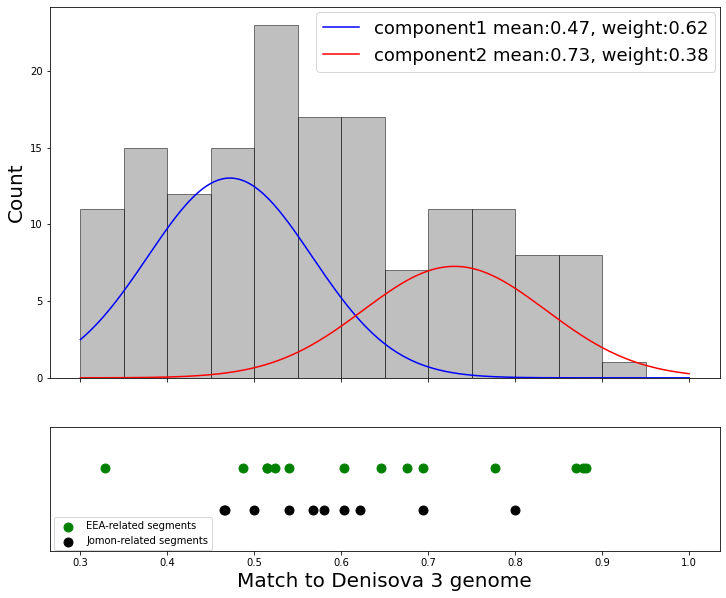

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

m1, m2 = 0.47200875, 0.73027459 
std1,std2 = 0.09456665, 0.10513146
weight1, weight2 = 0.61714269, 0.38285731 


# Plot the histogram
fig, ax = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1],sharex=True)
plt.subplots_adjust(wspace=2)
ax[0].hist(df_g['d3_match'],bins=[0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1.0], density=False, alpha=0.5, color='gray', edgecolor='black')

# Create a range of x values for plotting the distribution curves
x = np.linspace(df_g['d3_match'].min(), df_g['d3_match'].max(), 1000)
x = np.linspace(0.3,1,1000)

# Calculate the two normal distribution curves
curve1 = weight1 * norm.pdf(x, m1, std1)
curve2 = weight2 * norm.pdf(x, m2, std2)

# Add the bimodal distribution curves to the plot
ax[0].plot(x, curve1*5, color='blue', label='component1 mean:{:.2}, weight:{:.2}'.format(m1, weight1))
ax[0].plot(x, curve2*5, color='red', label='component2 mean:{:.2}, weight:{:.2}'.format(m2, weight2))
#ax[0].plot(x, curve1 + curve2, color='green', label='Bimodal Distribution', linewidth=2)
TY_Match = pd.DataFrame({"match":df_TY['match'].values})
JM_Match = pd.DataFrame({"match":df_JM['match'].values})
TY_Match['high'] = 10
JM_Match['high'] = 8
ax[1].scatter(TY_Match['match'],TY_Match['high'], color='green', label='EEA-related segments',marker='o', s=80)
ax[1].scatter(JM_Match['match'],JM_Match['high'], color='black', label='Jomon-related segments',marker='o', s=80)
# Customize the plot
#plt.suptitle('Distribution of Denisovan fragments in ancient and present-day East Asians', fontsize = 18)
#ax[0].set_xlabel('Match to Denisova3 genome', fontsize = 16)
ax[0].set_ylabel('Count', fontsize = 20)
ax[0].legend(prop={'size': 18}, loc='upper right',bbox_to_anchor=(1.007, 1.01))
ax[1].legend(prop={'size': 10}, loc='upper right',bbox_to_anchor=(0.25, 0.312))
ax[1].set_ylim(6,12)
ax[1].set_xlabel('Match to Denisova 3 genome', fontsize = 20)
ax[1].set_yticks([])
#plt.grid()
plt.show()
